In [109]:
# Import libraries
import sys
import os
import json
import pandas as pd
from pathlib import Path
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# Add the src directory to Python path
project_root = Path.cwd().parent.parent  # Go up to bonn_thesis/src/
sys.path.insert(0, str(project_root))

# Set pandas options
pd.set_option('display.max_columns', None)

from bonn_thesis.config import SOEP_DATA_BLD, LINKEDIN_MATCHED_TO_SOEP_BLD


## Load data

Data is loaded from the following files:
* wage_soep_exp_xx_results.jsonl: this file contains LLM labor income estimates using the OpenAI API. Metadata and description is saved to soep_metadata.csv
* soep_agg_part_xx.parquet: these are the individual-level observations used to generate profiles for OpenAI income estimates.

<br>Income estimates are extracted from the responses and there's a condition that income should be >10.000 euros. This is because the responses are limited to 20 tokens and some responses have extra characters (despite explicitly asking for numbers only). So it can happen that numbers appear not completely.
<br>Income is estimated yearly and converted to monthly income by dividing by 12 months to match the monthly gross labor income in SOEP
<br><br>After loading, the data is **grouped** by syear, isco_3_name, education_grouped, sex_en, and state_en to compute average wages within each demographic group.

In [110]:
# Define the experiment number you want to load
experiment_num = "14"

# Get all matching files
openai_responses_dir = SOEP_DATA_BLD / "openai_responses"
matching_files = sorted(openai_responses_dir.glob(f"wage_soep_exp_{experiment_num}*.jsonl"))

print(f"Found {len(matching_files)} files for experiment {experiment_num}:")
for file in matching_files:
    print(f"  - {file.name}")

# Load all matching files
openai_data = []
for file_path in matching_files:
    with open(file_path, 'r') as f:
        for line in f:
            openai_data.append(json.loads(line))

print(f"\nTotal responses loaded: {len(openai_data)}")

Found 5 files for experiment 14:
  - wage_soep_exp_14a_results.jsonl
  - wage_soep_exp_14b_results.jsonl
  - wage_soep_exp_14c_results.jsonl
  - wage_soep_exp_14d_results.jsonl
  - wage_soep_exp_14e_results.jsonl

Total responses loaded: 70378


In [111]:
# Load SOEP aggregated data
soep_agg_path = SOEP_DATA_BLD / "aggregated" / "soep_agg_part_14.parquet"
soep_df = pd.read_parquet(soep_agg_path)

In [112]:
# Extract wage estimates from OpenAI responses
def extract_wage(response_obj):
    """Extract numeric wage from OpenAI response content."""
    try:
        # Get the content from the response
        content = response_obj['response']['body']['choices'][0]['message']['content']
        
        # Remove common text patterns
        content = content.lower()
        content = content.replace('approximately', '')
        content = content.replace('estimate:', '')
        content = content.replace('euros', '')
        content = content.replace('euro', '')
        content = content.replace('€', '')
        content = content.replace(',', '')
        content = content.replace('.', '')
        content = content.strip()
        
        # Extract first number found
        numbers = re.findall(r'\d+', content)
        if numbers:
            wage = float(numbers[0])
            if wage > 10000:
                return wage
        return None
    except:
        return None

# Create DataFrame with custom_id and extracted wages
openai_df = pd.DataFrame([
    {
        'custom_id': item['custom_id'],
        'llm_income': extract_wage(item)
    }
    for item in openai_data
])

print(f"Successfully extracted {openai_df['llm_income'].notna().sum()} wages")

Successfully extracted 70257 wages


In [113]:
# Merge datasets on custom_id
merged_df = openai_df.merge(soep_df, on='custom_id', how='inner')

# Rename variables to remove _mean suffix (individual data before grouping)
merged_df = merged_df.rename(columns={
    'pglabgro_mean': 'pglabgro',
    'pgexpft_mean': 'pgexpft'
})

# Remove n_obs column if it exists (will be recalculated after grouping)
if 'n_obs' in merged_df.columns:
    merged_df = merged_df.drop(columns=['n_obs'])

# Convert annual to monthly wage
merged_df["llm_income"] = merged_df["llm_income"]/12

print(f"Merged dataset has {len(merged_df)} rows")
print(f"\nColumns: {merged_df.columns.tolist()}")
print(f"\nMissing values:")
print(merged_df.isnull().sum())

Merged dataset has 70378 rows

Columns: ['custom_id', 'llm_income', 'hid', 'pid', 'syear', 'pgkldb2010', 'pgisco08', 'pgisced11', 'pgexpft', 'pgemplst', 'pglabgro', 'pglabnet_mean', 'sex', 'bula_h', 'isco_code', 'isco_3_digit', 'isco_2_digit', 'isco_1_digit', 'isco_1_name', 'isco_2_name', 'isco_3_name', 'isco_4_name', 'kldb_code', 'kldb_4_digit', 'kldb_3_digit', 'kldb_2_digit', 'kldb_1_digit', 'kldb_skill', 'isced_code', 'education', 'education_grouped', 'sex_en', 'bland_code', 'state_en', 'state_de']

Missing values:
custom_id              0
llm_income           121
hid                    0
pid                    0
syear                  0
pgkldb2010             0
pgisco08               0
pgisced11              0
pgexpft              228
pgemplst               0
pglabgro               0
pglabnet_mean          0
sex                    0
bula_h                 0
isco_code              0
isco_3_digit           0
isco_2_digit           0
isco_1_digit           0
isco_1_name            0
i

## Group data by demographics

Group individual observations by demographic characteristics and compute mean wages within each group.

In [114]:
# Filter out zero or negative wages BEFORE grouping
merged_df = merged_df[
    (merged_df['pglabgro'] > 0) & 
    (merged_df['llm_income'] > 0)
].copy()

# Create log wage variables for individual observations
merged_df['log_pglabgro'] = np.log(merged_df['pglabgro'])
merged_df['log_llm_income'] = np.log(merged_df['llm_income'])
merged_df['pgexpft_sq'] = (merged_df['pgexpft'] ** 2) / 100

# Group by demographic characteristics and compute means
groupby_vars = ['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en']

grouped_df = merged_df.groupby(groupby_vars).agg({
    'pglabgro': 'mean',
    'llm_income': 'mean',
    'pgexpft': 'mean',
    'pgexpft_sq': 'mean',
    'log_pglabgro': 'mean',
    'log_llm_income': 'mean',
    'custom_id': 'count'  # Count observations per group
}).reset_index()

# Rename columns
grouped_df = grouped_df.rename(columns={
    'pglabgro': 'pglabgro_mean',
    'llm_income': 'llm_income_mean',
    'pgexpft': 'pgexpft_mean',
    'pgexpft_sq': 'pgexpft_sq_mean',
    'log_pglabgro': 'log_pglabgro_mean',
    'log_llm_income': 'log_llm_income_mean',
    'custom_id': 'n_obs'
})

print(f"After grouping: {len(grouped_df)} demographic groups")
print(f"Total observations: {grouped_df['n_obs'].sum()}")
print(f"\nGroup size statistics:")
print(f"  Mean: {grouped_df['n_obs'].mean():.2f}")
print(f"  Median: {grouped_df['n_obs'].median():.0f}")
print(f"  Min: {grouped_df['n_obs'].min()}")
print(f"  Max: {grouped_df['n_obs'].max()}")

After grouping: 26997 demographic groups
Total observations: 70046

Group size statistics:
  Mean: 2.59
  Median: 1
  Min: 1
  Max: 53


## Filter by minimum group size

Filter out groups with too few observations to ensure reliable estimates.

In [115]:
# Set minimum number of observations per group
min_obs_per_group = 5

# Filter groups by minimum size
print(f"Before filtering: {len(grouped_df)} groups, {grouped_df['n_obs'].sum()} total observations")
print(f"\nGroup size distribution before filtering:")
print(f"  Mean: {grouped_df['n_obs'].mean():.2f}")
print(f"  Median: {grouped_df['n_obs'].median():.0f}")
print(f"  Min: {grouped_df['n_obs'].min()}")
print(f"  Max: {grouped_df['n_obs'].max()}")
print(f"  Groups with n_obs < {min_obs_per_group}: {(grouped_df['n_obs'] < min_obs_per_group).sum()}")

# Apply filter
grouped_df = grouped_df[grouped_df['n_obs'] >= min_obs_per_group].copy()

print(f"\n{'-'*60}")
print(f"After filtering (keeping groups with n_obs >= {min_obs_per_group}):")
print(f"  {len(grouped_df)} groups, {grouped_df['n_obs'].sum()} total observations")
print(f"\nGroup size distribution after filtering:")
print(f"  Mean: {grouped_df['n_obs'].mean():.2f}")
print(f"  Median: {grouped_df['n_obs'].median():.0f}")
print(f"  Min: {grouped_df['n_obs'].min()}")
print(f"  Max: {grouped_df['n_obs'].max()}")

Before filtering: 26997 groups, 70046 total observations

Group size distribution before filtering:
  Mean: 2.59
  Median: 1
  Min: 1
  Max: 53
  Groups with n_obs < 5: 23520

------------------------------------------------------------
After filtering (keeping groups with n_obs >= 5):
  3477 groups, 31841 total observations

Group size distribution after filtering:
  Mean: 9.16
  Median: 7
  Min: 5
  Max: 53


## Descriptive statistics & wage distributions

In [116]:
# Remove rows with missing wages from grouped data
valid_df = grouped_df.dropna(subset=['llm_income_mean']).copy()

# Compute measurement error based on group means
valid_df["measurement_error"] = valid_df['llm_income_mean'] - valid_df['pglabgro_mean']
valid_df["measurement_error_log"] = valid_df['log_llm_income_mean'] - valid_df['log_pglabgro_mean']

# Keep observations where measurement_error_log < 1.50 in absolute value
valid_df = valid_df[valid_df["measurement_error_log"].abs() < 1.5].copy()

# Return only values where pglabgro_mean is greater than 10000/12
valid_df = valid_df[valid_df["pglabgro_mean"] > 10000/12].copy()

print(f"After filtering, valid_df has {len(valid_df)} groups")
print(f"Total weighted observations: {valid_df['n_obs'].sum()}")

print(f"\nWage statistics (unweighted):")
print(f"    SOEP: mean={valid_df['pglabgro_mean'].mean():.4f}, std={valid_df['pglabgro_mean'].std():.4f}")
print(f"    OpenAI: mean={valid_df['llm_income_mean'].mean():.4f}, std={valid_df['llm_income_mean'].std():.4f}")

print(f"\nLog wage statistics (unweighted):")
print(f"    Log SOEP: mean={valid_df['log_pglabgro_mean'].mean():.4f}, std={valid_df['log_pglabgro_mean'].std():.4f}")
print(f"    Log OpenAI: mean={valid_df['log_llm_income_mean'].mean():.4f}, std={valid_df['log_llm_income_mean'].std():.4f}")

After filtering, valid_df has 3476 groups
Total weighted observations: 31836

Wage statistics (unweighted):
    SOEP: mean=3596.2780, std=1946.9287
    OpenAI: mean=3116.6669, std=1402.5867

Log wage statistics (unweighted):
    Log SOEP: mean=8.0239, std=0.4035
    Log OpenAI: mean=7.9625, std=0.3664


In [117]:
# Print summary statistics
print("\nWage Statistics (weighted)")
print(f"    SOEP: mean={np.average(valid_df['pglabgro_mean'], weights=valid_df['n_obs']):.2f}, std={np.sqrt(np.average((valid_df['pglabgro_mean'] - np.average(valid_df['pglabgro_mean'], weights=valid_df['n_obs']))**2, weights=valid_df['n_obs'])):.2f}")
print(f"    OpenAI: mean={np.average(valid_df['llm_income_mean'], weights=valid_df['n_obs']):.2f}, std={np.sqrt(np.average((valid_df['llm_income_mean'] - np.average(valid_df['llm_income_mean'], weights=valid_df['n_obs']))**2, weights=valid_df['n_obs'])):.2f}")

print(f"\nLog wage statistics (weighted):")
print(f"    Log SOEP: mean={np.average(valid_df['log_pglabgro_mean'], weights=valid_df['n_obs']):.2f}, std={np.sqrt(np.average((valid_df['log_pglabgro_mean'] - np.average(valid_df['log_pglabgro_mean'], weights=valid_df['n_obs']))**2, weights=valid_df['n_obs'])):.2f}")
print(f"    Log OpenAI: mean={np.average(valid_df['log_llm_income_mean'], weights=valid_df['n_obs']):.2f}, std={np.sqrt(np.average((valid_df['log_llm_income_mean'] - np.average(valid_df['log_llm_income_mean'], weights=valid_df['n_obs']))**2, weights=valid_df['n_obs'])):.2f}")


Wage Statistics (weighted)
    SOEP: mean=3534.70, std=1804.11
    OpenAI: mean=3084.67, std=1331.21

Log wage statistics (weighted):
    Log SOEP: mean=8.02, std=0.39
    Log OpenAI: mean=7.96, std=0.35


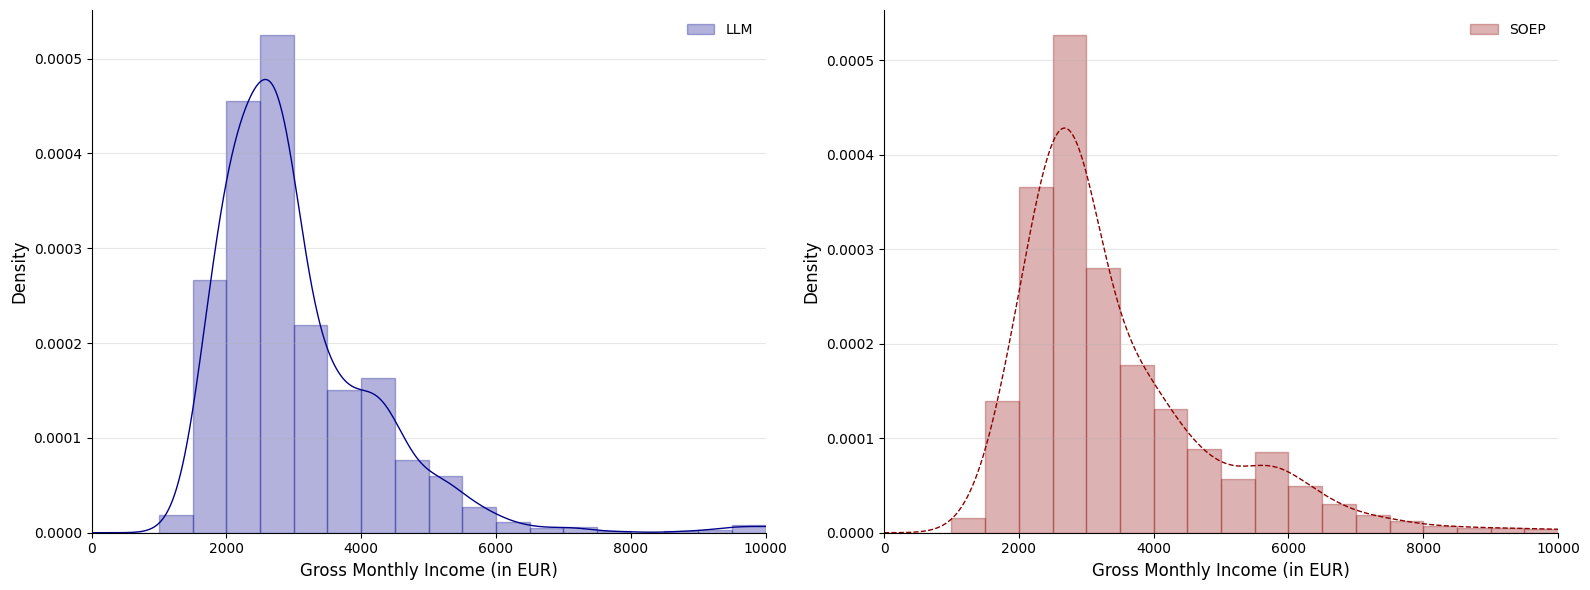

In [118]:
# Plot weighted wage distributions with 500 euro bins and density functions
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define bins of 500 euros
min_wage = 0
max_wage = 10000
bins = np.arange(0, max_wage + 500, 500)

# Plot OpenAI wage distribution (weighted)
counts, _, patches = axes[0].hist(valid_df['llm_income_mean'], bins=bins, weights=valid_df['n_obs'], 
                                   alpha=0.3, color='darkblue', edgecolor='darkblue', label='LLM', density=True)
# Add KDE
kde_openai = gaussian_kde(valid_df['llm_income_mean'], weights=valid_df['n_obs'])
x_range_openai = np.linspace(0, 10000, 1000)
axes[0].plot(x_range_openai, kde_openai(x_range_openai), color='darkblue', linewidth=1, linestyle='-')
axes[0].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_xlim(0, 10000)
axes[0].legend(frameon=False, fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Plot SOEP wage distribution (weighted)
counts, _, patches = axes[1].hist(valid_df['pglabgro_mean'], bins=bins, weights=valid_df['n_obs'], 
                                   alpha=0.3, color='darkred', edgecolor='darkred', label='SOEP', density=True)
# Add KDE
kde_soep = gaussian_kde(valid_df['pglabgro_mean'], weights=valid_df['n_obs'])
x_range = np.linspace(0, 10000, 1000)
axes[1].plot(x_range, kde_soep(x_range), color='darkred', linewidth=1, linestyle='--')
axes[1].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_xlim(0, 10000)
axes[1].legend(frameon=False, fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

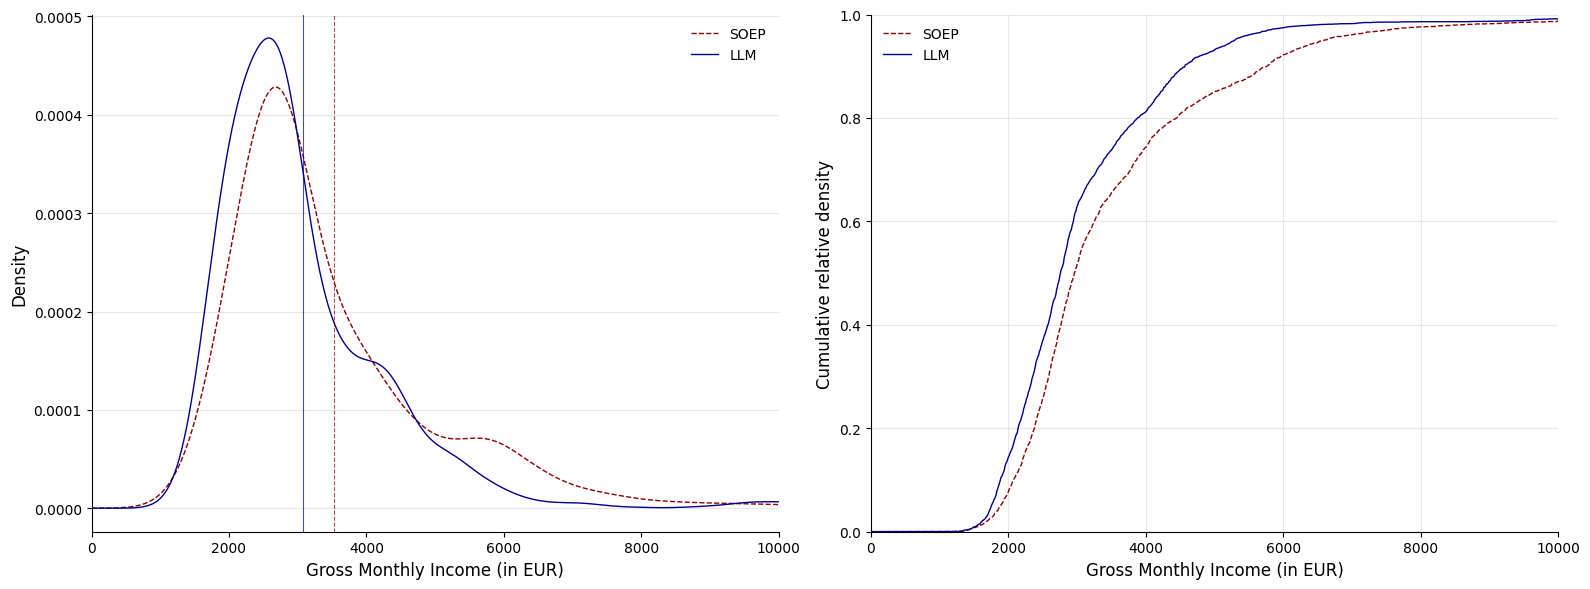

In [119]:
# Create density and cumulative density plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate weighted averages
soep_mean = np.average(valid_df['pglabgro_mean'], weights=valid_df['n_obs'])
openai_mean = np.average(valid_df['llm_income_mean'], weights=valid_df['n_obs'])

# Left panel: Density functions only
x_range_plot = np.linspace(0, 10000, 1000)
axes[0].plot(x_range_plot, kde_soep(x_range_plot), color='darkred', linewidth=1, linestyle='--', label='SOEP')
axes[0].plot(x_range_plot, kde_openai(x_range_plot), color='darkblue', linewidth=1, linestyle='-', label='LLM')

# Add vertical lines for averages
axes[0].axvline(soep_mean, color='darkred', linewidth=0.8, linestyle='--', alpha=0.7)
axes[0].axvline(openai_mean, color='darkblue', linewidth=0.8, linestyle='-', alpha=0.7)

axes[0].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_xlim(0, 10000)
axes[0].legend(fontsize=10, frameon=False)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Right panel: Cumulative density functions
# Calculate empirical CDFs using weighted observations
def weighted_ecdf(data, weights, x_eval):
    """Calculate weighted empirical CDF at evaluation points."""
    sorted_indices = np.argsort(data)
    sorted_data = data[sorted_indices]
    sorted_weights = weights[sorted_indices]
    cumsum_weights = np.cumsum(sorted_weights)
    total_weight = cumsum_weights[-1]
    
    # Normalize to [0, 1]
    cumsum_weights = cumsum_weights / total_weight
    
    # Evaluate at x_eval points
    cdf_values = np.searchsorted(sorted_data, x_eval, side='right')
    cdf_values = np.clip(cdf_values - 1, 0, len(cumsum_weights) - 1)
    
    result = np.zeros(len(x_eval))
    for i, idx in enumerate(cdf_values):
        if idx >= 0:
            result[i] = cumsum_weights[idx]
    
    return result

cdf_soep = weighted_ecdf(valid_df['pglabgro_mean'].values, valid_df['n_obs'].values, x_range_plot)
cdf_openai = weighted_ecdf(valid_df['llm_income_mean'].values, valid_df['n_obs'].values, x_range_plot)

axes[1].plot(x_range_plot, cdf_soep, color='darkred', linewidth=1, linestyle='--', label='SOEP')
axes[1].plot(x_range_plot, cdf_openai, color='darkblue', linewidth=1, linestyle='-', label='LLM')

axes[1].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[1].set_ylabel('Cumulative relative density', fontsize=12)
axes[1].set_xlim(0, 10000)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=10, frameon=False)
axes[1].grid(True, alpha=0.3)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

## Correlation between SOEP and LLM income data

In [120]:
# Compute correlation coefficient (weighted by n_obs)

# Weighted correlation using numpy
weights = valid_df['n_obs'].values
weighted_cov = np.cov(valid_df['llm_income_mean'], valid_df['pglabgro_mean'], aweights=weights)
correlation = weighted_cov[0, 1] / np.sqrt(weighted_cov[0, 0] * weighted_cov[1, 1])

# Also compute unweighted for comparison
unweighted_corr = valid_df['llm_income_mean'].corr(valid_df['pglabgro_mean'])

print(f"Weighted correlation coefficient: {correlation:.4f}")
print(f"Unweighted correlation coefficient: {unweighted_corr:.4f}")
print(f"\nNumber of groups: {len(valid_df)}")
print(f"Total weighted observations: {valid_df['n_obs'].sum():.0f}")

Weighted correlation coefficient: 0.8008
Unweighted correlation coefficient: 0.7784

Number of groups: 3476
Total weighted observations: 31836


In [121]:
# Compute spearman correlation
from scipy.stats import spearmanr

spearman_unweighted = valid_df[['llm_income_mean', 'pglabgro_mean']].corr(method='spearman')
unweighted_rho = spearman_unweighted.loc['llm_income_mean', 'pglabgro_mean']

print(f"Spearman correlation coefficient (unweighted): {unweighted_rho:.4f}")

Spearman correlation coefficient (unweighted): 0.8014


## Income ranking (SOEP vs LLM)

## Measurement error distributions
Measurement error is defined as the difference between LLM estimates and the true survey labor income.

In [122]:
# Measurement error descriptives (weighted by n_obs)
me = valid_df['measurement_error']
me_log = valid_df['measurement_error_log']


weights = valid_df['n_obs']
print(f"Number of observations: {len(me_log)}")

print(f"Total weighted observations: {weights.sum():.0f}")

print("Weighted Measurement Error Statistics (EUR):")
print(f"  Median (approx): {me.median():.4f}")

print(f"  Mean: {np.average(me, weights=weights):.4f}")
print(f"  Max: {me.max():.4f}")

print(f"  Std: {np.sqrt(np.average((me - np.average(me, weights=weights))**2, weights=weights)):.4f}")
print(f"  Min: {me.min():.4f}")

print("Weighted Measurement Error Statistics (log points):")
print(f"  Median (approx): {me_log.median():.4f}")

print(f"  Mean: {np.average(me_log, weights=weights):.4f}")
print(f"  Max: {me_log.max():.4f}")

print(f"  Std: {np.sqrt(np.average((me_log - np.average(me_log, weights=weights))**2, weights=weights)):.4f}")
print(f"  Min: {me_log.min():.4f}")

Number of observations: 3476
Total weighted observations: 31836
Weighted Measurement Error Statistics (EUR):
  Median (approx): -288.6222
  Mean: -450.0209
  Max: 5881.2500
  Std: 1086.5335
  Min: -15683.3333
Weighted Measurement Error Statistics (log points):
  Median (approx): -0.0590
  Mean: -0.0583
  Max: 1.2482
  Std: 0.2072
  Min: -1.1104


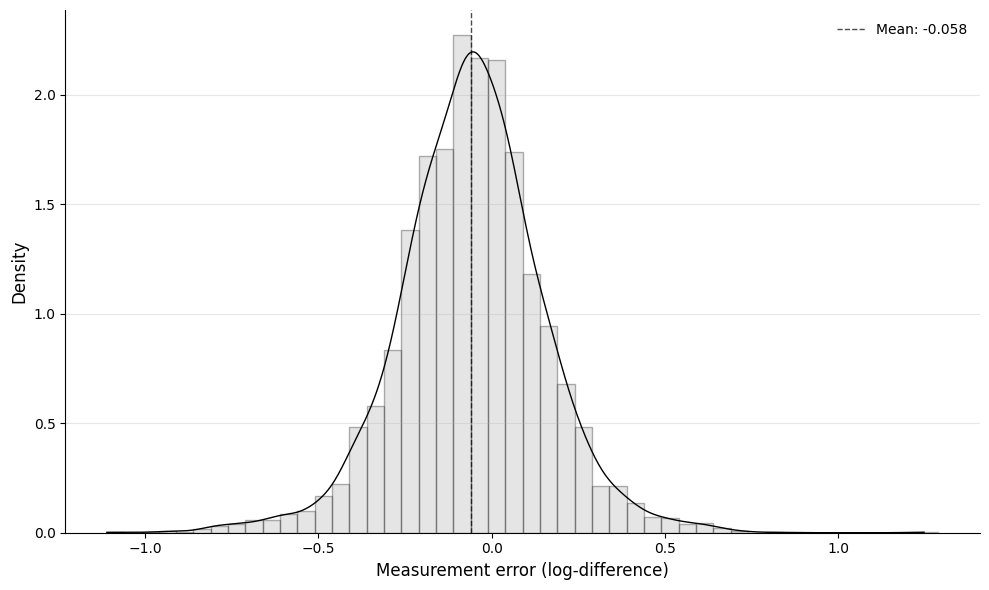

In [123]:
# Plot measurement error distribution in logs
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Calculate weighted mean of measurement error
me_mean = np.average(valid_df['measurement_error_log'], weights=valid_df['n_obs'])

# Define bins of 0.05
bins = np.arange(valid_df['measurement_error_log'].min(), valid_df['measurement_error_log'].max() + 0.05, 0.05)

# Plot histogram
ax.hist(valid_df['measurement_error_log'], bins=bins, weights=valid_df['n_obs'], 
        alpha=0.3, color='darkgrey', edgecolor='black', density=True)

# Add KDE
kde_me = gaussian_kde(valid_df['measurement_error_log'], weights=valid_df['n_obs'])
x_range = np.linspace(valid_df['measurement_error_log'].min(), valid_df['measurement_error_log'].max(), 1000)
ax.plot(x_range, kde_me(x_range), color='black', linewidth=1, linestyle='-')

# Add vertical line for mean
ax.axvline(me_mean, color='black', linewidth=1, linestyle='--', alpha=0.7, label=f'Mean: {me_mean:.3f}')

ax.set_xlabel('Measurement error (log-difference)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=10, frameon=False)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


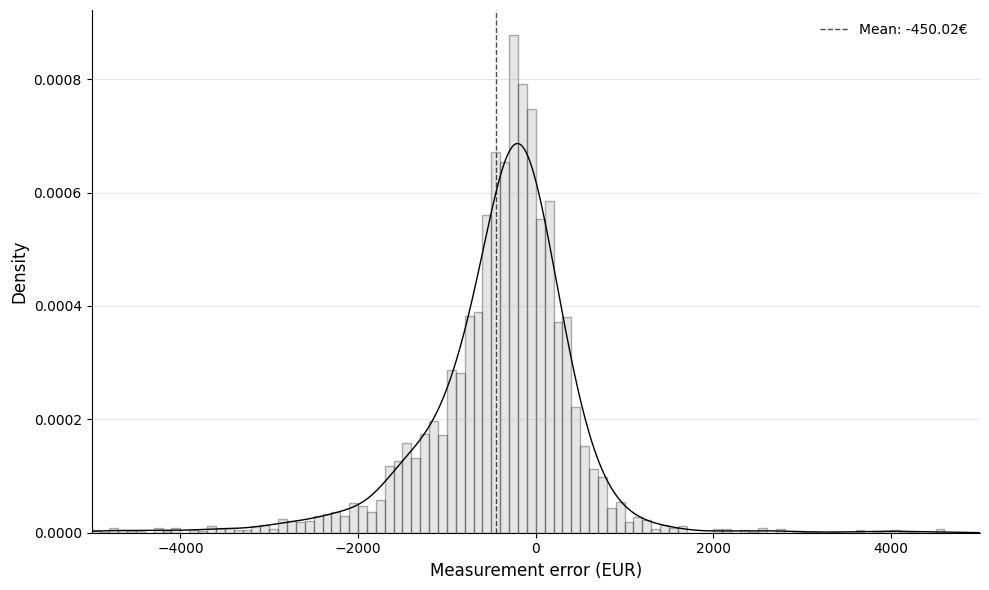

In [124]:
# Plot nominal measurement error distribution
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Calculate weighted mean of measurement error
me_mean = np.average(valid_df['measurement_error'], weights=valid_df['n_obs'])

# Define bins (50 euro bins) and limit range to -5000 to +5000
bin_width = 100
bins = np.arange(-5000, 5000 + bin_width, bin_width)

# Plot histogram
ax.hist(valid_df['measurement_error'], bins=bins, weights=valid_df['n_obs'], 
        alpha=0.3, color='darkgrey', edgecolor='black', density=True)

# Add KDE
kde_me = gaussian_kde(valid_df['measurement_error'], weights=valid_df['n_obs'])
x_range = np.linspace(-5000, 5000, 1000)
ax.plot(x_range, kde_me(x_range), color='black', linewidth=1, linestyle='-')

# Add vertical line for mean
ax.axvline(me_mean, color='black', linewidth=1, linestyle='--', alpha=0.7, label=f'Mean: {me_mean:.2f}€')

ax.set_xlabel('Measurement error (EUR)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_xlim(-5000, 5000)
ax.legend(fontsize=10, frameon=False)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


In [125]:
# Share of observations with negative measurement error
neg_mask = valid_df['measurement_error'] < 0

# Unweighted share across groups
share_neg_unweighted = neg_mask.mean()

# Weighted share by number of observations in each group
share_neg_weighted = np.average(neg_mask.astype(float), weights=valid_df['n_obs'])

print(f"Share with negative measurement error (unweighted): {share_neg_unweighted:.4f} ({share_neg_unweighted*100:.2f}%)")
print(f"Share with negative measurement error (weighted by n_obs): {share_neg_weighted:.4f} ({share_neg_weighted*100:.2f}%)")

Share with negative measurement error (unweighted): 0.7132 (71.32%)
Share with negative measurement error (weighted by n_obs): 0.7269 (72.69%)


/var/folders/5h/mgjr5c410p33q26211w0wr640000gn/T/ipykernel_39707/3803211000.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_stats_euro = valid_df.groupby('income_quantile').agg({
/var/folders/5h/mgjr5c410p33q26211w0wr640000gn/T/ipykernel_39707/3803211000.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_stats_log = valid_df.groupby('income_quantile').agg({


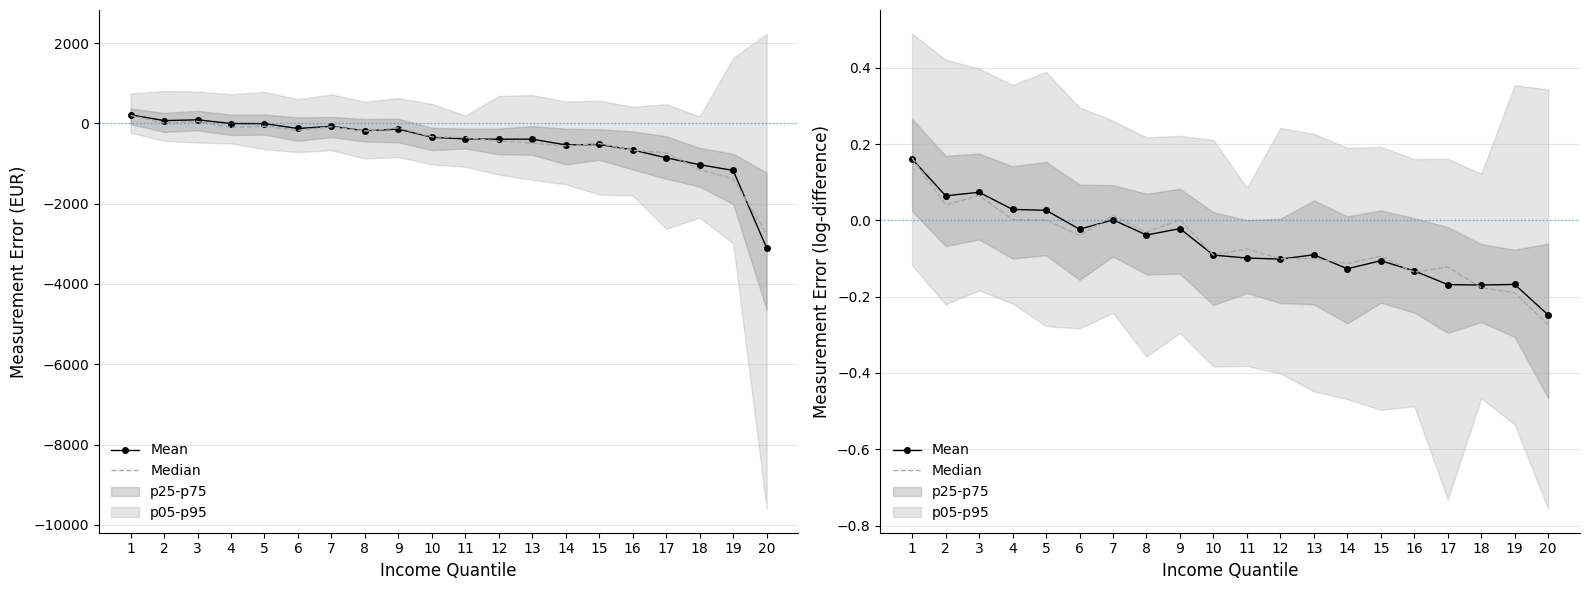

In [126]:
# Measurement error distribution by earning quantiles

# Create 20 quantiles based on SOEP earnings
valid_df['income_quantile'] = pd.qcut(valid_df['pglabgro_mean'], q=20, labels=range(1, 21))

# Calculate statistics for each quantile (in euros)
quantile_stats_euro = valid_df.groupby('income_quantile').agg({
    'measurement_error': ['mean', 'median', 
                          lambda x: x.quantile(0.05),
                          lambda x: x.quantile(0.25), 
                          lambda x: x.quantile(0.75),
                          lambda x: x.quantile(0.95)]
}).reset_index()
quantile_stats_euro.columns = ['quantile', 'mean', 'median', 'p05', 'p25', 'p75', 'p95']

# Calculate statistics for each quantile (in logs)
quantile_stats_log = valid_df.groupby('income_quantile').agg({
    'measurement_error_log': ['mean', 'median',
                              lambda x: x.quantile(0.05),
                              lambda x: x.quantile(0.25),
                              lambda x: x.quantile(0.75),
                              lambda x: x.quantile(0.95)]
}).reset_index()
quantile_stats_log.columns = ['quantile', 'mean', 'median', 'p05', 'p25', 'p75', 'p95']

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Measurement error in euros
axes[0].fill_between(quantile_stats_euro['quantile'], quantile_stats_euro['p05'], quantile_stats_euro['p95'],
                      alpha=0.2, color='grey', label='p05-p95')
axes[0].fill_between(quantile_stats_euro['quantile'], quantile_stats_euro['p25'], quantile_stats_euro['p75'],
                      alpha=0.3, color='grey', label='p25-p75')
axes[0].plot(quantile_stats_euro['quantile'], quantile_stats_euro['mean'], 
             color='black', linewidth=1, linestyle='-', marker='o', markersize=4, label='Mean')
axes[0].plot(quantile_stats_euro['quantile'], quantile_stats_euro['median'],
             color='darkgrey', linewidth=1, linestyle='--', markersize=4, label='Median')
axes[0].axhline(0, linewidth=1, linestyle=':', alpha=0.5)
axes[0].set_xlabel('Income Quantile', fontsize=12)
axes[0].set_ylabel('Measurement Error (EUR)', fontsize=12)
axes[0].set_xticks(range(1, 21))
axes[0].set_xticklabels(range(1, 21))
# Reorder legend: mean, median, p25-p75, p05-p95
handles, labels = axes[0].get_legend_handles_labels()
order = [2, 3, 1, 0]  # mean, median, p25-p75, p05-p95
axes[0].legend([handles[i] for i in order], [labels[i] for i in order], fontsize=10, frameon=False)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Right panel: Measurement error in logs
axes[1].fill_between(quantile_stats_log['quantile'], quantile_stats_log['p05'], quantile_stats_log['p95'],
                      alpha=0.2, color='grey', label='p05-p95')
axes[1].fill_between(quantile_stats_log['quantile'], quantile_stats_log['p25'], quantile_stats_log['p75'],
                      alpha=0.3, color='grey', label='p25-p75')
axes[1].plot(quantile_stats_log['quantile'], quantile_stats_log['mean'],
             color='black', linewidth=1, linestyle='-', marker='o', markersize=4, label='Mean')
axes[1].plot(quantile_stats_log['quantile'], quantile_stats_log['median'],
             color='darkgrey', linewidth=1, linestyle='--', markersize=4, label='Median')
axes[1].axhline(0, linewidth=1, linestyle=':', alpha=0.5)
axes[1].set_xlabel('Income Quantile', fontsize=12)
axes[1].set_ylabel('Measurement Error (log-difference)', fontsize=12)
axes[1].set_xticks(range(1, 21))
axes[1].set_xticklabels(range(1, 21))
# Reorder legend: mean, median, p25-p75, p05-p95
handles, labels = axes[1].get_legend_handles_labels()
order = [2, 3, 1, 0]  # mean, median, p25-p75, p05-p95
axes[1].legend([handles[i] for i in order], [labels[i] for i in order], fontsize=10, frameon=False)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


## Correlation with observables and Mincer regressions

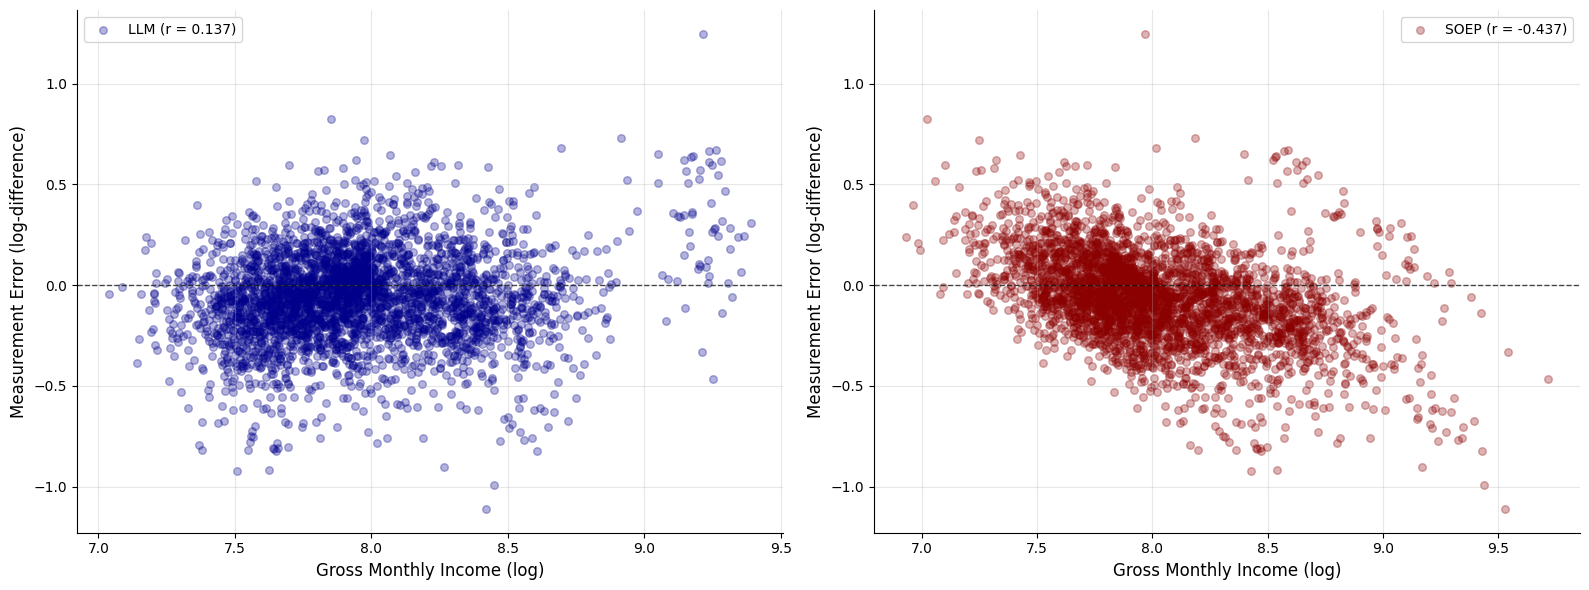

In [127]:
# Scatter plot: Measurement error vs income levels
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate correlations
corr_llm = valid_df['log_llm_income_mean'].corr(valid_df['measurement_error_log'])
corr_soep = valid_df['log_pglabgro_mean'].corr(valid_df['measurement_error_log'])

# Left panel: Measurement error vs LLM income
axes[0].scatter(valid_df['log_llm_income_mean'], valid_df['measurement_error_log'], 
                alpha=0.3, color='darkblue', s=30, label=f'LLM (r = {corr_llm:.3f})')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
axes[0].set_xlabel('Gross Monthly Income (log)', fontsize=12)
axes[0].set_ylabel('Measurement Error (log-difference)', fontsize=12)
axes[0].legend(fontsize=10, frameon=True)
axes[0].grid(True, alpha=0.3)
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Right panel: Measurement error vs SOEP income
axes[1].scatter(valid_df['log_pglabgro_mean'], valid_df['measurement_error_log'], 
                alpha=0.3, color='darkred', s=30, label=f'SOEP (r = {corr_soep:.3f})')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
axes[1].set_xlabel('Gross Monthly Income (log)', fontsize=12)
axes[1].set_ylabel('Measurement Error (log-difference)', fontsize=12)
axes[1].legend(fontsize=10, frameon=True)
axes[1].grid(True, alpha=0.3)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

In [128]:
valid_df['llm_income_mean'].value_counts().sort_index().tail(50)

llm_income_mean
8744.047619     1
8916.666667     1
8988.095238     1
9125.000000     1
9166.666667     1
9226.190476     1
9343.750000     1
9356.060606     1
9519.927536     1
9583.333333     1
9583.333333     2
9607.142857     1
9611.111111     1
9659.090909     1
9677.083333     1
9772.727273     1
9843.750000     1
9861.111111     1
9916.666667     1
10000.000000    2
10041.666667    1
10054.166667    1
10069.444444    1
10138.888889    1
10156.250000    1
10203.703704    1
10277.777778    1
10277.777778    1
10300.000000    1
10333.333333    1
10341.666667    1
10416.666667    2
10416.666667    1
10486.111111    1
10535.714286    1
10572.916667    1
10625.000000    1
10661.764706    1
10730.769231    1
10833.333333    1
10833.333333    1
10916.666667    1
10937.500000    1
11111.111111    1
11212.121212    1
11250.000000    2
11458.333333    1
11750.000000    1
11805.555556    1
12000.000000    1
Name: count, dtype: int64

In [129]:
# Prepare dataframes

covariates = ['sex_en', 'education_grouped', 'state_en', 'isco_3_name', 'syear', 'pgexpft_mean', 'pgexpft_sq_mean']

# Prepare the data for regression - drop any rows with missing values in key variables
regression_df = valid_df[['measurement_error_log', 'log_llm_income_mean', 'log_pglabgro_mean', 'n_obs'] + covariates].dropna().copy()
regression_df['syear'] = regression_df['syear'].astype(str)

print(f"Observations for regression: {len(regression_df)}")
print(f"Weighted observations: {regression_df['n_obs'].sum():.0f}")

Observations for regression: 3476
Weighted observations: 31836


In [130]:
# Regression of measurement error (log) on covariates

# Combine all features
X = pd.get_dummies(regression_df[covariates], drop_first=True, dtype=float)

# Add constant
X = sm.add_constant(X)

# Dependent variable
y = regression_df['measurement_error_log'].values

# Weights
weights = regression_df['n_obs'].values

# Fit weighted OLS with robust standard errors
model = sm.WLS(y, X, weights=weights)
results = model.fit(cov_type='HC3')  # HC3 robust standard errors

# Print regression summary
print("="*80)
print("Weighted OLS Regression: Measurement Error (log) on Covariates")
print("="*80)
print(results.summary())
print("\n")

# F-statistic for H0: all coefficients = 0 (except constant)
# Get indices of all coefficients except constant
non_const_indices = [i for i in range(len(results.params)) if i != 0]
f_test = results.f_test(np.eye(len(results.params))[non_const_indices])
print(f"F-statistic for H0: all β = 0: {f_test.fvalue:.4f}")
print(f"P-value: {f_test.pvalue:.4e}")
print("\n")

# Calculate R-squared
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred = results.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred, sample_weight=weights))
mae = mean_absolute_error(y, y_pred, sample_weight=weights)

print(f"Weighted RMSE: {rmse:.4f}")
print(f"Weighted MAE: {mae:.4f}")
print("="*80)

Weighted OLS Regression: Measurement Error (log) on Covariates
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.557
Model:                            WLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     43.03
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:29:25   Log-Likelihood:                 1716.6
No. Observations:                3476   AIC:                            -3201.
Df Residuals:                    3360   BIC:                            -2487.
Df Model:                         115                                         
Covariance Type:                  HC3                                         
                                                                                                    coef    std err          z      P>|z|      [0.0

In [131]:
# Regression of log_llm_income_mean on covariates
# Using the same feature matrix X from the previous regression

# Dependent variable - log LLM income
y_llm = regression_df['log_llm_income_mean'].values

# Fit weighted OLS with robust standard errors (using same X and weights)
model_llm = sm.WLS(y_llm, X, weights=weights)
results_llm = model_llm.fit(cov_type='HC3')  # HC3 robust standard errors

# Print regression summary
print("="*80)
print("Weighted OLS Regression: log(LLM Income) on Covariates")
print("="*80)
print(results_llm.summary())
print("\n")

# F-statistic for H0: all coefficients = 0 (except constant)
# Get indices of all coefficients except constant
non_const_indices = [i for i in range(len(results_llm.params)) if i != 0]
f_test_llm = results_llm.f_test(np.eye(len(results_llm.params))[non_const_indices])
print(f"F-statistic for H0: all β = 0: {f_test_llm.fvalue:.4f}")
print(f"P-value: {f_test_llm.pvalue:.4e}")
print("\n")

# Calculate R-squared
print(f"R-squared: {results_llm.rsquared:.4f}")
print(f"Adjusted R-squared: {results_llm.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred_llm = results_llm.predict(X)
rmse_llm = np.sqrt(mean_squared_error(y_llm, y_pred_llm, sample_weight=weights))
mae_llm = mean_absolute_error(y_llm, y_pred_llm, sample_weight=weights)

print(f"Weighted RMSE: {rmse_llm:.4f}")
print(f"Weighted MAE: {mae_llm:.4f}")
print("="*80)

Weighted OLS Regression: log(LLM Income) on Covariates
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.980
Model:                            WLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     1261.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:29:26   Log-Likelihood:                 5243.5
No. Observations:                3476   AIC:                        -1.025e+04
Df Residuals:                    3360   BIC:                            -9541.
Df Model:                         115                                         
Covariance Type:                  HC3                                         
                                                                                                    coef    std err          z      P>|z|      [0.025      

In [132]:
# Regression of log_pglabgro_mean (SOEP wages) on covariates
# Using the same feature matrix X from the previous regressions

# Dependent variable - log SOEP income
y_soep = regression_df['log_pglabgro_mean'].values

# Fit weighted OLS with robust standard errors (using same X and weights)
model_soep = sm.WLS(y_soep, X, weights=weights)
results_soep = model_soep.fit(cov_type='HC3')  # HC3 robust standard errors

# Print regression summary
print("="*80)
print("Weighted OLS Regression: log(SOEP Income) on Covariates")
print("="*80)
print(results_soep.summary())
print("\n")

# F-statistic for H0: all coefficients = 0 (except constant)
# Get indices of all coefficients except constant
non_const_indices = [i for i in range(len(results_soep.params)) if i != 0]
f_test_soep = results_soep.f_test(np.eye(len(results_soep.params))[non_const_indices])
print(f"F-statistic for H0: all β = 0: {f_test_soep.fvalue:.4f}")
print(f"P-value: {f_test_soep.pvalue:.4e}")
print("\n")

# Calculate R-squared
print(f"R-squared: {results_soep.rsquared:.4f}")
print(f"Adjusted R-squared: {results_soep.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred_soep = results_soep.predict(X)
rmse_soep = np.sqrt(mean_squared_error(y_soep, y_pred_soep, sample_weight=weights))
mae_soep = mean_absolute_error(y_soep, y_pred_soep, sample_weight=weights)

print(f"Weighted RMSE: {rmse_soep:.4f}")
print(f"Weighted MAE: {mae_soep:.4f}")
print("="*80)

Weighted OLS Regression: log(SOEP Income) on Covariates
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.886
Model:                            WLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     423.2
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:29:26   Log-Likelihood:                 1919.8
No. Observations:                3476   AIC:                            -3608.
Df Residuals:                    3360   BIC:                            -2894.
Df Model:                         115                                         
Covariance Type:                  HC3                                         
                                                                                                    coef    std err          z      P>|z|      [0.025     

In [133]:
# Create comparison table of regression results

# Function to format coefficient with std error and significance
def format_coef(coef, se, pval):
    """Format coefficient with standard error and significance stars"""
    stars = ''
    if pval < 0.001:
        stars = '***'
    elif pval < 0.01:
        stars = '**'
    elif pval < 0.05:
        stars = '*'
    return f"{coef:.4f}{stars}\n({se:.4f})"


def pretty_var_name(var_name):
    """Map technical variable names to presentation labels."""
    if var_name == 'pgexpft_mean':
        return 'Experience'
    if var_name == 'pgexpft_sq_mean':
        return 'Experience^2'
    if var_name.startswith('sex_'):
        sex_label = var_name.replace('sex_', '')
        if sex_label == 'en_male':
            return 'Male'
        return sex_label
    if var_name.startswith('education_grouped_'):
        edu_label = var_name.replace('education_grouped_', '')
        if edu_label == 'Post-secondary non-tertiary or Short-cycle tertiary education':
            return 'Post-secondary'
        return edu_label
    if var_name.startswith('state_'):
        return var_name.replace('state_', '')
    if var_name.startswith('isco_3_name_'):
        return var_name.replace('isco_3_name_', '')
    if var_name.startswith('syear_'):
        return var_name.replace('syear_', '')
    return var_name

# Extract parameters from all three models
params_me = results.params
se_me = results.bse
pval_me = results.pvalues

params_llm = results_llm.params
se_llm = results_llm.bse
pval_llm = results_llm.pvalues

params_soep = results_soep.params
se_soep = results_soep.bse
pval_soep = results_soep.pvalues

# Create list of rows for the table
table_data = []

# Group variables by type
sex_vars = [v for v in params_me.index if v.startswith('sex_')]
education_vars = [v for v in params_me.index if v.startswith('education_')]
occupation_vars = [v for v in params_me.index if v.startswith('occupation_')]
state_vars = [v for v in params_me.index if v.startswith('state_')]
year_vars = [v for v in params_me.index if v.startswith('syear_')]
experience_vars = ['pgexpft_mean', 'pgexpft_sq_mean']

# Add constant
if 'const' in params_me.index:
    table_data.append({
        'Variable': 'Constant',
        'Measurement Error': format_coef(params_me['const'], se_me['const'], pval_me['const']),
        'LLM Income': format_coef(params_llm['const'], se_llm['const'], pval_llm['const']),
        'SOEP Income': format_coef(params_soep['const'], se_soep['const'], pval_soep['const'])
    })

# Add experience variables
table_data.append({'Variable': '--- Experience ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
for var in experience_vars:
    if var in params_me.index:
        table_data.append({
            'Variable': pretty_var_name(var),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add sex variables
if sex_vars:
    table_data.append({'Variable': '--- Sex ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
    for var in sex_vars:
        table_data.append({
            'Variable': pretty_var_name(var),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add education variables
if education_vars:
    table_data.append({'Variable': '--- Education ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
    for var in education_vars:
        table_data.append({
            'Variable': pretty_var_name(var),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add top 5 occupation variables by absolute coefficient value (using measurement error)
if occupation_vars:
    occ_abs_coefs = {var: abs(params_me[var]) for var in occupation_vars}
    top_5_occ = sorted(occ_abs_coefs.items(), key=lambda x: x[1], reverse=True)[:5]
    table_data.append({'Variable': '--- Occupation (Top 5) ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
    for var, _ in top_5_occ:
        table_data.append({
            'Variable': pretty_var_name(var),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add top 5 state variables by absolute coefficient value (using measurement error)
if state_vars:
    state_abs_coefs = {var: abs(params_me[var]) for var in state_vars}
    top_5_state = sorted(state_abs_coefs.items(), key=lambda x: x[1], reverse=True)[:5]
    table_data.append({'Variable': '--- State (Top 5) ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
    for var, _ in top_5_state:
        table_data.append({
            'Variable': pretty_var_name(var),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add model statistics
table_data.append({'Variable': '', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})
table_data.append({'Variable': '--- Model Statistics ---', 'Measurement Error': '', 'LLM Income': '', 'SOEP Income': ''})

# Time fixed effects
time_fe = 'Yes' if year_vars else 'No'
table_data.append({
    'Variable': 'Time Fixed Effects',
    'Measurement Error': time_fe,
    'LLM Income': time_fe,
    'SOEP Income': time_fe
})

# F-statistic
table_data.append({
    'Variable': 'F-statistic',
    'Measurement Error': f"{f_test.fvalue:.2f}",
    'LLM Income': f"{f_test_llm.fvalue:.2f}",
    'SOEP Income': f"{f_test_soep.fvalue:.2f}"
})

# R-squared
table_data.append({
    'Variable': 'R-squared',
    'Measurement Error': f"{results.rsquared:.4f}",
    'LLM Income': f"{results_llm.rsquared:.4f}",
    'SOEP Income': f"{results_soep.rsquared:.4f}"
})

# Number of observations
table_data.append({
    'Variable': 'Observations',
    'Measurement Error': f"{int(results.nobs)}",
    'LLM Income': f"{int(results_llm.nobs)}",
    'SOEP Income': f"{int(results_soep.nobs)}"
})

# Create DataFrame and display
comparison_table = pd.DataFrame(table_data)
print("="*100)
print("REGRESSION RESULTS COMPARISON")
print("="*100)
print("\nNote: Standard errors in parentheses. *** p<0.001, ** p<0.01, * p<0.05")
print("\n")
print(comparison_table.to_string(index=False))
print("\n" + "="*100)

REGRESSION RESULTS COMPARISON

Note: Standard errors in parentheses. *** p<0.001, ** p<0.01, * p<0.05


                 Variable    Measurement Error           LLM Income          SOEP Income
                 Constant    -0.0217\n(0.0611)  7.9715***\n(0.0168)  7.9932***\n(0.0521)
       --- Experience ---                                                               
               Experience -0.0310***\n(0.0023)  0.0071***\n(0.0008)  0.0381***\n(0.0022)
             Experience^2  0.0550***\n(0.0054) -0.0094***\n(0.0019) -0.0645***\n(0.0052)
              --- Sex ---                                                               
                     Male -0.0755***\n(0.0090)  0.0660***\n(0.0034)  0.1416***\n(0.0087)
        --- Education ---                                                               
Master or Doctoral degree  0.0645***\n(0.0147)  0.1454***\n(0.0056)  0.0809***\n(0.0136)
           Post-secondary     0.0084\n(0.0152) -0.1088***\n(0.0056) -0.1172***\n(0.0135)
      

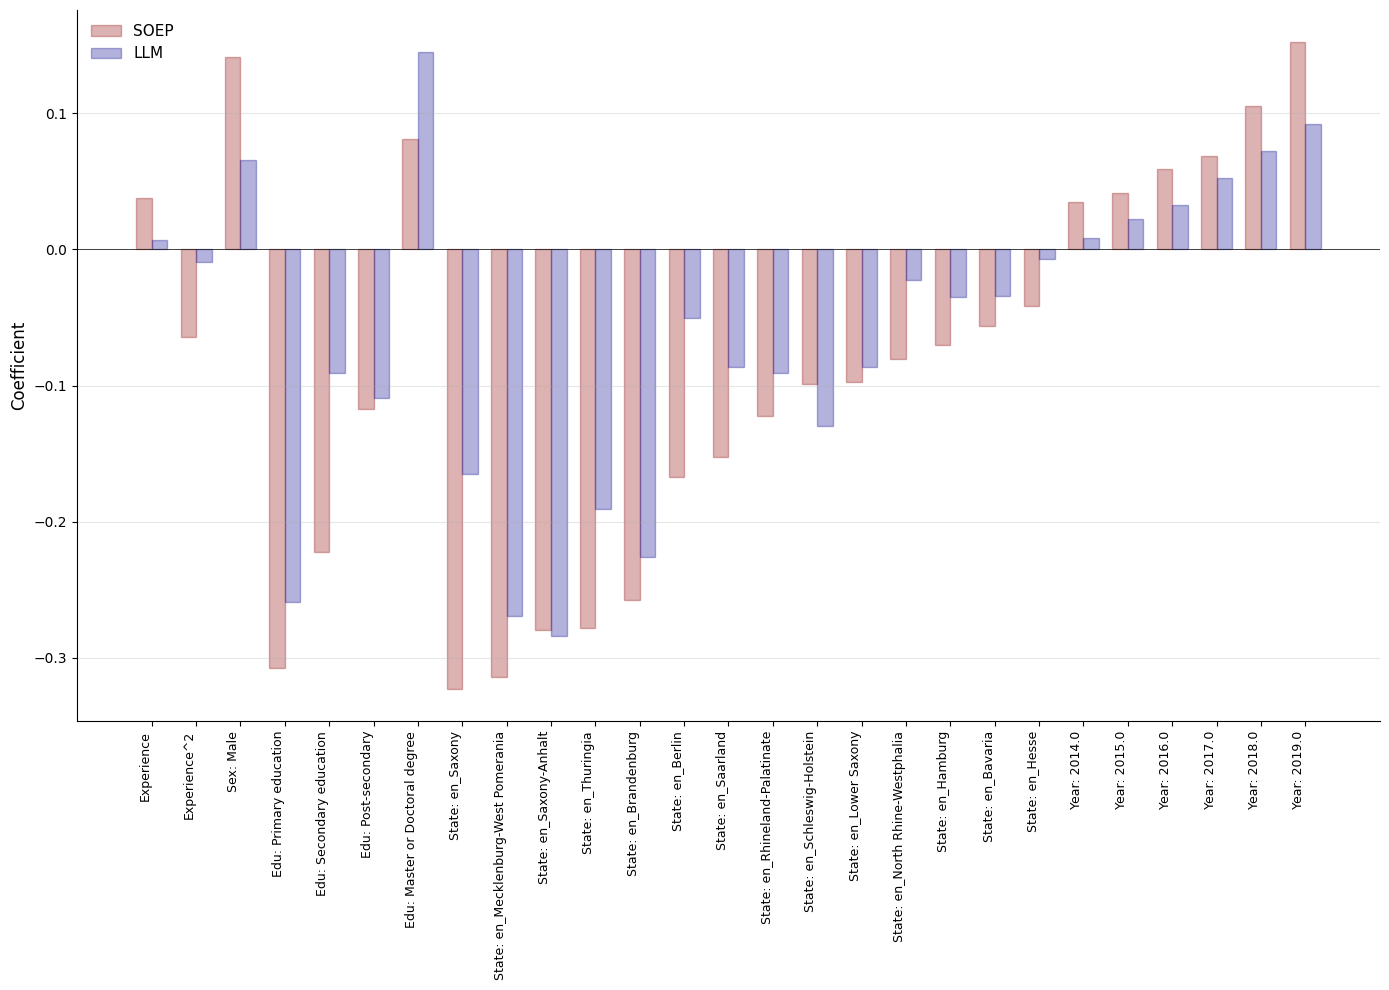

In [134]:
# Visualize coefficient comparison between LLM and SOEP

# Extract coefficients for variables of interest
experience_vars = ['pgexpft_mean', 'pgexpft_sq_mean']
sex_vars = [v for v in params_llm.index if v.startswith('sex_')]
education_vars = [v for v in params_llm.index if v.startswith('education_')]
state_vars = [v for v in params_llm.index if v.startswith('state_')]
year_vars = [v for v in params_llm.index if v.startswith('syear_')]

# Sort each category by absolute SOEP coefficient value
sex_vars_sorted = sorted(sex_vars, key=lambda x: abs(params_soep[x]), reverse=True)
education_vars_sorted = sorted(education_vars, key=lambda x: abs(params_soep[x]), reverse=True)
state_vars_sorted = sorted(state_vars, key=lambda x: abs(params_soep[x]), reverse=True)

# Combine all variables (experience stays in original order)
plot_vars = experience_vars + sex_vars_sorted + education_vars_sorted + state_vars_sorted + year_vars


def pretty_plot_label(var_name):
    """Map technical variable names to readable plot labels."""
    if var_name == 'pgexpft_mean':
        return 'Experience'
    if var_name == 'pgexpft_sq_mean':
        return 'Experience^2'
    if var_name.startswith('sex_'):
        sex_label = var_name.replace('sex_', '')
        if sex_label == 'en_male':
            sex_label = 'Male'
        return f'Sex: {sex_label}'
    if var_name.startswith('education_'):
        edu_label = var_name.replace('education_grouped_', '')
        if edu_label == 'Post-secondary non-tertiary or Short-cycle tertiary education':
            edu_label = 'Post-secondary'
        return f'Edu: {edu_label}'
    if var_name.startswith('state_'):
        return var_name.replace('state_', 'State: ')
    if var_name.startswith('syear_'):
        return var_name.replace('syear_', 'Year: ')
    return var_name

# Create labels (clean variable names)
labels = []
llm_coefs = []
soep_coefs = []

for var in plot_vars:
    if var in params_llm.index and var in params_soep.index:
        labels.append(pretty_plot_label(var))
        llm_coefs.append(params_llm[var])
        soep_coefs.append(params_soep[var])

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Set up bar positions
x = np.arange(len(labels))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, soep_coefs, width, label='SOEP', color='darkred', edgecolor='darkred', alpha=0.3)
bars2 = ax.bar(x + width/2, llm_coefs, width, label='LLM', color='darkblue', edgecolor='darkblue', alpha=0.3)

# Customize plot
ax.set_ylabel('Coefficient', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=9)
ax.legend(fontsize=11, frameon=False)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

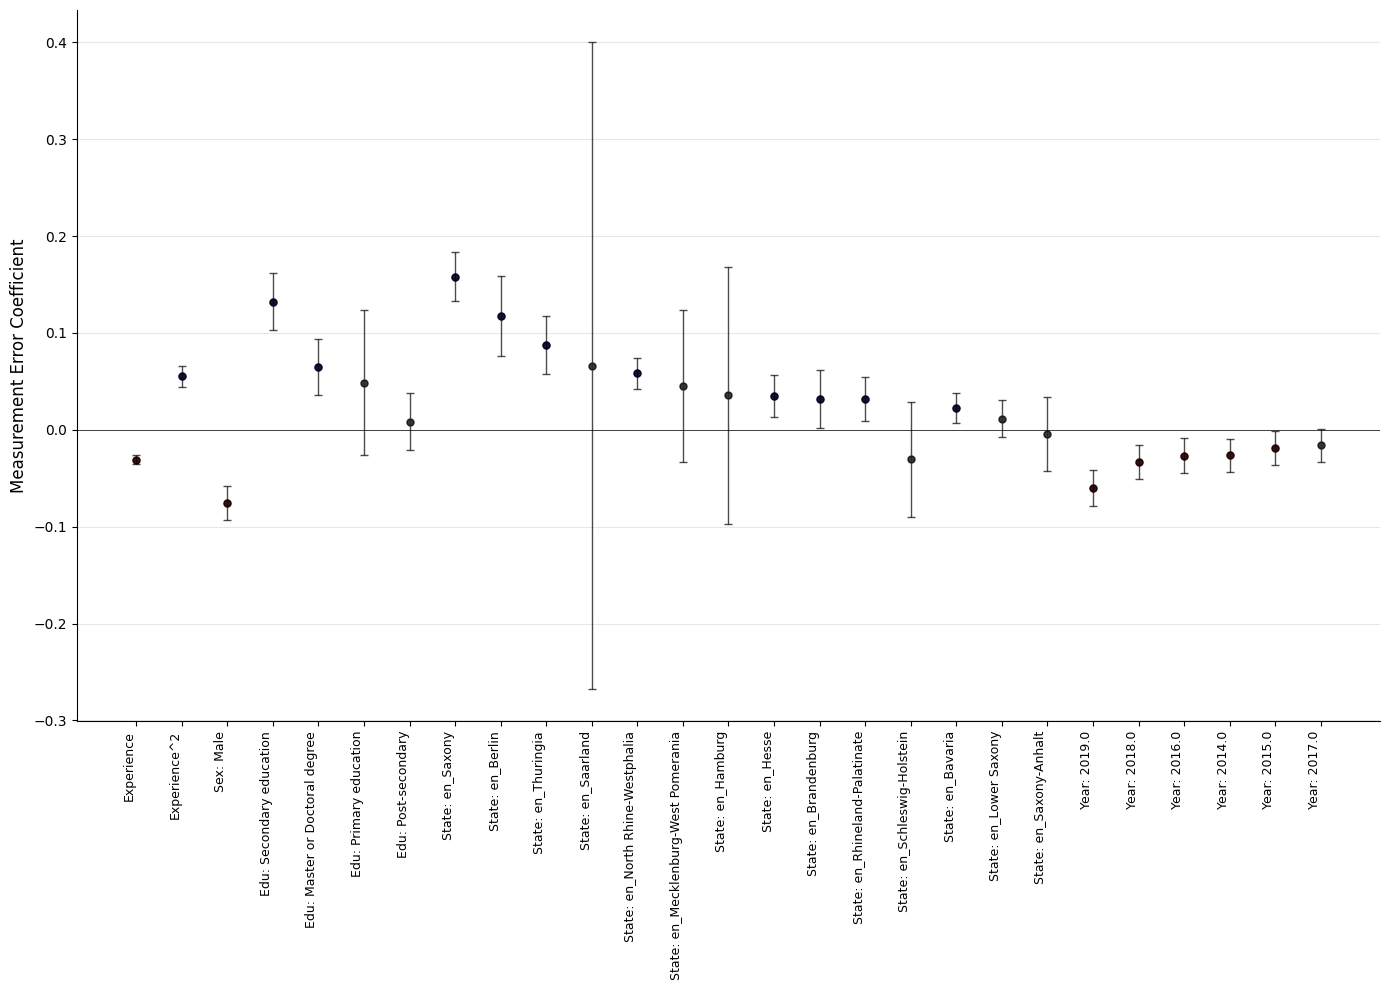

In [135]:
# Visualize measurement error coefficients with confidence intervals

# Extract coefficients for variables of interest
experience_vars = ['pgexpft_mean', 'pgexpft_sq_mean']
sex_vars = [v for v in params_llm.index if v.startswith('sex_')]
education_vars = [v for v in params_llm.index if v.startswith('education_')]
state_vars = [v for v in params_llm.index if v.startswith('state_')]
year_vars = [v for v in params_llm.index if v.startswith('syear_')]

# Sort each category by absolute measurement error coefficient value
sex_vars_sorted = sorted(sex_vars, key=lambda x: abs(params_me[x]), reverse=True)
education_vars_sorted = sorted(education_vars, key=lambda x: abs(params_me[x]), reverse=True)
state_vars_sorted = sorted(state_vars, key=lambda x: abs(params_me[x]), reverse=True)
year_vars_sorted = sorted(year_vars, key=lambda x: abs(params_me[x]), reverse=True)

# Combine all variables (experience stays in original order)
plot_vars = experience_vars + sex_vars_sorted + education_vars_sorted + state_vars_sorted + year_vars_sorted


def pretty_plot_label(var_name):
    """Map technical variable names to readable plot labels."""
    if var_name == 'pgexpft_mean':
        return 'Experience'
    if var_name == 'pgexpft_sq_mean':
        return 'Experience^2'
    if var_name.startswith('sex_'):
        sex_label = var_name.replace('sex_', '')
        if sex_label == 'en_male':
            sex_label = 'Male'
        return f'Sex: {sex_label}'
    if var_name.startswith('education_'):
        edu_label = var_name.replace('education_grouped_', '')
        if edu_label == 'Post-secondary non-tertiary or Short-cycle tertiary education':
            edu_label = 'Post-secondary'
        return f'Edu: {edu_label}'
    if var_name.startswith('state_'):
        return var_name.replace('state_', 'State: ')
    if var_name.startswith('syear_'):
        return var_name.replace('syear_', 'Year: ')
    return var_name

# Create labels and extract coefficients with standard errors
labels = []
me_coefs = []
me_se = []

for var in plot_vars:
    if var in params_me.index:
        labels.append(pretty_plot_label(var))
        me_coefs.append(params_me[var])
        me_se.append(se_me[var])

# Convert to arrays
me_coefs = np.array(me_coefs)
me_se = np.array(me_se)

# Calculate 95% confidence intervals (1.96 * SE)
ci_95 = 1.96 * me_se

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Set up positions
x = np.arange(len(labels))

# Plot coefficients with error bars
# Color points based on whether CI includes zero
colors = ['darkgrey' if (coef - ci < 0 and coef + ci > 0) else ('darkred' if coef < 0 else 'darkblue') 
          for coef, ci in zip(me_coefs, ci_95)]

ax.errorbar(x, me_coefs, yerr=ci_95, fmt='o', color='black', ecolor='black', 
            capsize=3, capthick=1, markersize=5, linewidth=1, alpha=0.7)

# Color the points
for i, (xi, yi, color) in enumerate(zip(x, me_coefs, colors)):
    ax.plot(xi, yi, 'o', color=color, markersize=5, alpha=0.7)

# Customize plot
ax.set_ylabel('Measurement Error Coefficient', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=9)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

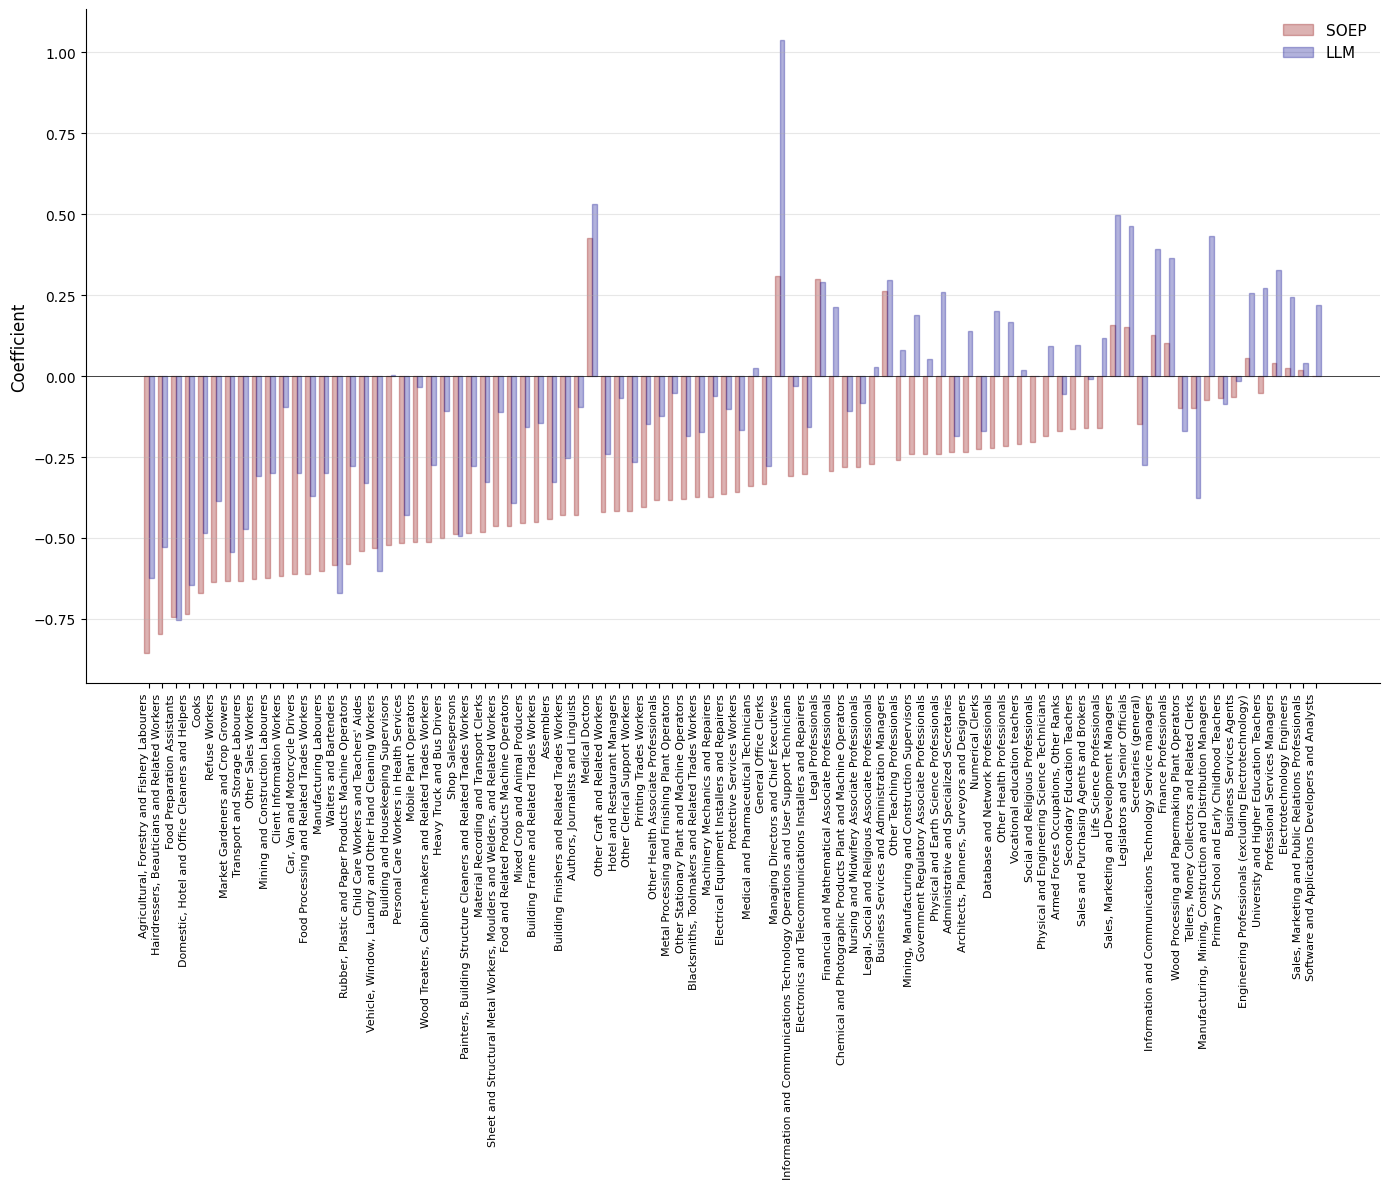

In [136]:
# Visualize coefficient comparison between LLM and SOEP for occupations

# Extract occupation variables
occupation_vars = [v for v in params_llm.index if v.startswith('isco_3_name_')]

# Sort by absolute SOEP coefficient value
occupation_vars_sorted = sorted(occupation_vars, key=lambda x: abs(params_soep[x]), reverse=True)

# Create labels and extract coefficients
labels = []
llm_coefs = []
soep_coefs = []

for var in occupation_vars_sorted:
    if var in params_llm.index and var in params_soep.index:
        # Clean up variable name for display
        label = var.replace('isco_3_name_', '')
        
        labels.append(label)
        llm_coefs.append(params_llm[var])
        soep_coefs.append(params_soep[var])

# Create figure
fig, ax = plt.subplots(figsize=(14, 12))

# Set up bar positions
x = np.arange(len(labels))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, soep_coefs, width, label='SOEP', color='darkred', edgecolor='darkred', alpha=0.3)
bars2 = ax.bar(x + width/2, llm_coefs, width, label='LLM', color='darkblue', edgecolor='darkblue', alpha=0.3)

# Customize plot
ax.set_ylabel('Coefficient', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=8)
ax.legend(fontsize=11, frameon=False)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [137]:
valid_df_sorted = valid_df.copy()
valid_df_sorted['abs_measurement_error_log'] = valid_df_sorted['measurement_error_log'].abs()
valid_df_sorted = valid_df_sorted.sort_values('pglabgro_mean', ascending=False)

In [138]:
valid_df.columns

Index(['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en',
       'pglabgro_mean', 'llm_income_mean', 'pgexpft_mean', 'pgexpft_sq_mean',
       'log_pglabgro_mean', 'log_llm_income_mean', 'n_obs',
       'measurement_error', 'measurement_error_log', 'income_quantile'],
      dtype='object')

In [139]:
# Display top rows
valid_df_sorted[valid_df_sorted["pgexpft_mean"] < 5][["measurement_error_log","measurement_error", "llm_income_mean", "pglabgro_mean", "isco_3_name","syear", "education_grouped", "pgexpft_mean"]].head(500)

,measurement_error_log,measurement_error,llm_income_mean,pglabgro_mean,isco_3_name,syear,education_grouped,pgexpft_mean
22442,-0.218406,-813.611111,3701.388889,4515.000000,Secondary Education Teachers,2018.0,Master or Doctoral degree,4.861167
18473,-0.058875,-286.666667,3433.333333,3720.000000,"Sales, Marketing and Public Relations Professi...",2017.0,Bachelor degree,2.366600
14578,0.050155,260.933333,3958.333333,3697.400000,Secondary Education Teachers,2016.0,Master or Doctoral degree,3.766800
7119,0.223044,713.333333,4033.333333,3320.000000,Secondary Education Teachers,2014.0,Master or Doctoral degree,3.683200
10920,0.239013,569.703704,3870.370370,3300.666667,Secondary Education Teachers,2015.0,Master or Doctoral degree,4.111000
14586,0.351696,534.222222,3680.555556,3146.333333,Secondary Education Teachers,2016.0,Master or Doctoral degree,3.791667
25454,-0.063686,-226.190476,2773.809524,3000.000000,Nursing and Midwifery Associate Professionals,2019.0,Post-secondary non-tertiary or Short-cycle ter...,4.827357
22450,0.226928,499.000000,3400.000000,2901.000000,Secondary Education Teachers,2018.0,Master or Doctoral degree,4.683600
7114,0.337837,783.833333,3645.833333,2862.000000,Secondary Education Teachers,2014.0,Master or Doctoral degree,4.020833
26395,0.381167,966.277778,3819.444444,2853.166667,Secondary Education Teachers,2019.0,Master or Doctoral degree,4.361167


In [140]:
# Compute mean weighted measurement error by n_obs

# Group by n_obs and calculate weighted mean measurement error
me_by_nobs = valid_df.groupby('n_obs').apply(
    lambda x: np.average(x['measurement_error_log'], weights=x['n_obs'])
).reset_index()
me_by_nobs.columns = ['n_obs', 'mean_me_log']

# Also calculate the total weighted observations for each n_obs group (for reference)
obs_by_nobs = valid_df.groupby('n_obs').size().reset_index(name='count')
obs_by_nobs['total_weighted_obs'] = obs_by_nobs['n_obs'] * obs_by_nobs['count']
obs_by_nobs = obs_by_nobs[['n_obs', 'total_weighted_obs']]

# Merge
me_by_nobs = me_by_nobs.merge(obs_by_nobs, on='n_obs')

# Sort by n_obs
me_by_nobs = me_by_nobs.sort_values('n_obs')

print("Mean Weighted Measurement Error by n_obs:")
print(me_by_nobs.head(20))
print(f"\nTotal groups: {len(me_by_nobs)}")


Mean Weighted Measurement Error by n_obs:
    n_obs  mean_me_log  total_weighted_obs
0       5    -0.069426                4555
1       6    -0.065312                3720
2       7    -0.084858                2891
3       8    -0.043813                2576
4       9    -0.057508                2079
5      10    -0.055583                1530
6      11    -0.027445                1320
7      12    -0.051568                1344
8      13    -0.038318                1027
9      14    -0.025053                1050
10     15    -0.053943                 840
11     16    -0.054141                 752
12     17    -0.014999                 476
13     18    -0.059647                 648
14     19    -0.055189                 589
15     20    -0.043632                 520
16     21    -0.089730                 798
17     22    -0.073794                 308
18     23    -0.013614                 391
19     24    -0.084186                 528

Total groups: 44


/var/folders/5h/mgjr5c410p33q26211w0wr640000gn/T/ipykernel_39707/1041954085.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  me_by_nobs = valid_df.groupby('n_obs').apply(


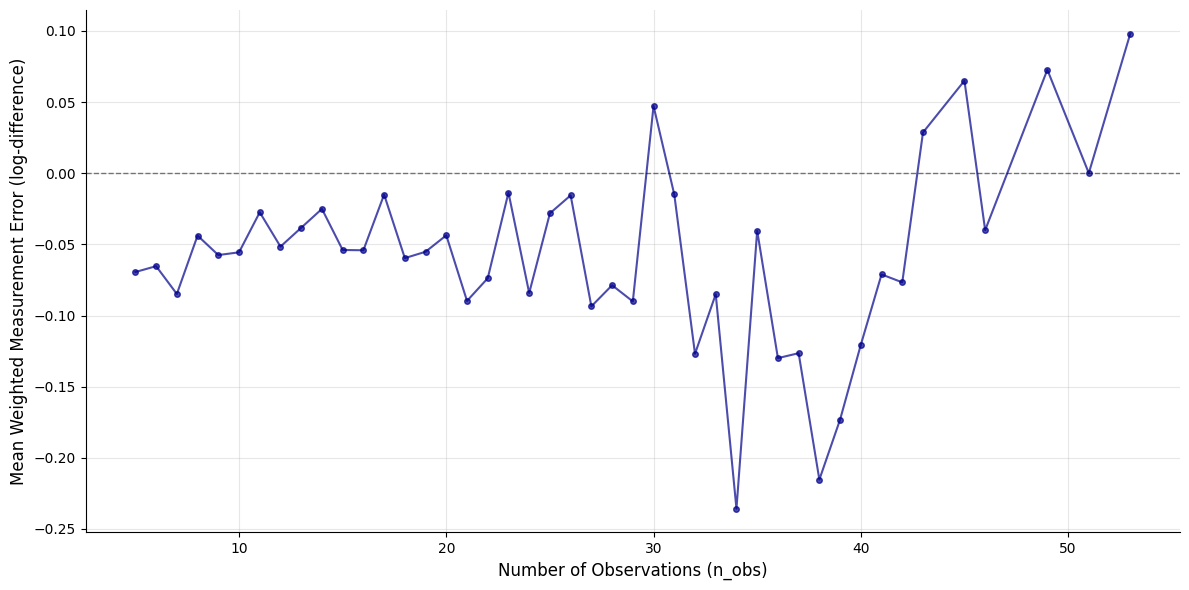

In [141]:
# Visualize mean weighted measurement error by n_obs

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot mean measurement error
ax.plot(me_by_nobs['n_obs'], me_by_nobs['mean_me_log'], 
        color='darkblue', linewidth=1.5, marker='o', markersize=4, alpha=0.7)

# Add horizontal line at zero
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)

ax.set_xlabel('Number of Observations (n_obs)', fontsize=12)
ax.set_ylabel('Mean Weighted Measurement Error (log-difference)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


In [142]:
me_by_nobs

,n_obs,mean_me_log,total_weighted_obs
0,5,-0.069426,4555
1,6,-0.065312,3720
2,7,-0.084858,2891
3,8,-0.043813,2576
4,9,-0.057508,2079
5,10,-0.055583,1530
6,11,-0.027445,1320
7,12,-0.051568,1344
8,13,-0.038318,1027
9,14,-0.025053,1050


/Users/willbackes/Documents/code/bonn_thesis/src/bld/tables/mincer_comparison_table.csv
(23, 4)
